# Naive Bayes (NB)
Naive Bayes is een eenvoudige maar krachtige probabilistische classificatiemethode gebaseerd op de Bayesiaanse statistiek. Het model maakt gebruik van de Bayes' theorema om de waarschijnlijkheid te berekenen dat een gegeven invoer tot een bepaalde klasse behoort, op basis van de kenmerken van de invoer. Het "naive" aspect van het model verwijst naar de aanname dat alle kenmerken onafhankelijk zijn van elkaar, wat in de praktijk vaak niet het geval is, maar toch verrassend goede resultaten kan opleveren. Naive Bayes is vooral effectief bij tekstclassificatieproblemen, zoals spamdetectie en sentimentanalyse, vanwege zijn efficiëntie en vermogen om goed te presteren met beperkte trainingsdata.

In [7]:
import sys
import os

# Add the parent directory (project root) to Python path
project_root = os.path.abspath('..')  # Go up one level from current notebook
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB, ComplementNB
import warnings
warnings.filterwarnings('ignore')


from libs_generic_functions import LibsDataLoader, LibsDataPreprocessor
from baseline_correction_functions import BaselineCorrector, analyze_correction_quality, print_quality_report

In [ ]:
%%time
data_loader = LibsDataLoader(data_directory='../data/')
df_individual = data_loader.load_all_measurements()

In [ ]:
%%time
Preprocessor = LibsDataPreprocessor()
df_individual = Preprocessor.prepare_ml_data(df_individual) 

PREPARING DATA FOR MACHINE LEARNING
Feature matrix shape: (51453, 8188)
Target distribution:
origin
tread         17936
innerliner    17260
sidewall      16257
Name: count, dtype: int64
CPU times: total: 21.9 s
Wall time: 23.9 s
Feature matrix shape: (51453, 8188)
Target distribution:
origin
tread         17936
innerliner    17260
sidewall      16257
Name: count, dtype: int64
CPU times: total: 21.9 s
Wall time: 23.9 s


In [19]:
X_train, X_test, y_train, y_test = Preprocessor.split_data(df_individual[0], df_individual[1], test_size=0.2, random_state=42)

Training set: (41162, 8188)
Test set: (10291, 8188)
Training distribution:
origin
tread         14349
innerliner    13808
sidewall      13005
Name: count, dtype: int64
Test distribution:
origin
tread         3587
innerliner    3452
sidewall      3252
Name: count, dtype: int64


# Comprehensive Naive Bayes Analysis
In deze sectie voeren we een uitgebreide Naive Bayes analyse uit, vergelijkbaar met onze andere ML analyses. We testen verschillende Naive Bayes varianten en vergelijken de prestaties met en zonder dimensionaliteitsreductie. Naive Bayes is bijzonder interessant voor spectroscopische data vanwege zijn probabilistische aanpak en efficiëntie.

In [ ]:
%%time
import time

# Import the baseline correction module

print("Baseline correction functions imported successfully!")

# Create baseline corrector instance
corrector = BaselineCorrector()

# Apply Hybrid 4S+AsLS baseline correction to training and test data
print(f"\nApplying Hybrid 4S+AsLS baseline correction to LIBS data...")
print(f"Original training data shape: {X_train.shape}")
print(f"Original test data shape: {X_test.shape}")

start_time = time.time()

# Apply baseline correction to training data
print("Correcting training data...")
X_train_corrected = corrector.apply_correction_batch(
    X_train, 
    method='hybrid',
    batch_size=100,
    window_length=51, 
    polyorder=3, 
    als_lam=1e4, 
    als_p=0.01
)

# Apply baseline correction to test data  
print("Correcting test data...")
X_test_corrected = corrector.apply_correction_batch(
    X_test,
    method='hybrid',
    batch_size=100,
    window_length=51,
    polyorder=3,
    als_lam=1e4,
    als_p=0.01
)

correction_time = time.time() - start_time

# Convert back to DataFrames with original column names
X_train_corrected_df = pd.DataFrame(X_train_corrected, 
                                   columns=X_train.columns, 
                                   index=X_train.index)
X_test_corrected_df = pd.DataFrame(X_test_corrected, 
                                  columns=X_test.columns, 
                                  index=X_test.index)

print(f"✅ Baseline correction completed in {correction_time:.1f} seconds")
print(f"Corrected training data shape: {X_train_corrected_df.shape}")
print(f"Corrected test data shape: {X_test_corrected_df.shape}")

# Quality analysis using the new functions
quality_metrics = analyze_correction_quality(
    X_train, 
    X_train_corrected, 
    class_labels=y_train.values
)
print_quality_report(quality_metrics)

# Visualization of baseline correction effect
print(f"\nCreating baseline correction visualization...")

# Select a representative spectrum for visualization
sample_idx = 42  # Use a fixed index for reproducibility
sample_spectrum_orig = X_train.iloc[sample_idx].values
wavelengths = np.array([float(col) for col in X_train.columns])

# Use the new visualization method
corrector.visualize_correction(
    sample_spectrum_orig,
    wavelengths=wavelengths,
    method='hybrid',
    window_length=51,
    polyorder=3,
    als_lam=1e4,
    als_p=0.01
)

# Additional class-wise intensity analysis
class_stats_orig = []
class_stats_corr = []
classes = y_train_ind.unique()

for cls in classes:
    cls_mask = y_train == cls
    orig_mean = np.mean(X_train[cls_mask].values)
    corr_mean = np.mean(X_train_corrected[cls_mask])
    class_stats_orig.append(orig_mean)
    class_stats_corr.append(corr_mean)

# Create additional class comparison visualization
plt.figure(figsize=(10, 6))
x_pos = np.arange(len(classes))
width = 0.35

plt.bar(x_pos - width/2, class_stats_orig, width, label='Original', alpha=0.7, color='lightblue')
plt.bar(x_pos + width/2, class_stats_corr, width, label='Baseline Corrected', alpha=0.7, color='lightgreen')
plt.title('Mean Intensity by Class - Before vs After Baseline Correction')
plt.xlabel('Tire Component')
plt.ylabel('Mean Intensity')
plt.xticks(x_pos, classes)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n🎯 Ready for Naive Bayes analysis with baseline-corrected data!")
print(f"   • Applied: Hybrid 4S+AsLS baseline correction")
print(f"   • Processing time: {correction_time:.1f} seconds")
print(f"   • Training samples: {len(X_train_corrected_df):,}")
print(f"   • Test samples: {len(X_test_corrected_df):,}")
print(f"   • Features: {X_train_corrected_df.shape[1]}")

# Update the data variables to use baseline-corrected versions
print(f"\nUpdating data variables to use baseline-corrected spectra...")
X_train_original = X_train_corrected_df.copy()
X_test_original = X_test_corrected_df.copy()

print(f"\n💡 Baseline Correction Summary:")
print(f"   • Method: Hybrid 4S Peak Filling + AsLS")
print(f"   • Quality report shows statistical changes")
print(f"   • Visualization confirms proper baseline removal")
print(f"   • Data ready for machine learning analysis")

NAIVE BAYES DATA PREPROCESSING
Training set shape: (41162, 8188)
Test set shape: (10291, 8188)
Data preprocessing completed!
Data preprocessing completed!


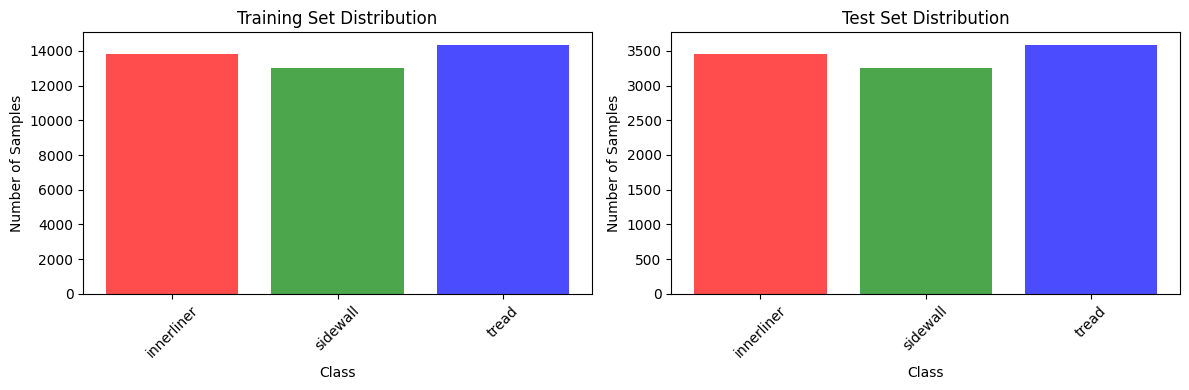


Label encoder mapping:
  innerliner → 0
  sidewall → 1
  tread → 2

Data preparation summary:
  Original: (41162, 8188) (for GaussianNB)
  Scaled: (41162, 8188) (for GaussianNB + dimensionality reduction)
  Non-negative: (41162, 8188) (for MultinomialNB, ComplementNB)
  Binary: (41162, 8188) (for BernoulliNB)
CPU times: total: 20 s
Wall time: 22 s


In [5]:
%%time
# Data Preprocessing for Naive Bayes Analysis
print("=" * 70)
print("NAIVE BAYES DATA PREPROCESSING")
print("=" * 70)

# Encode labels to numeric values
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_individual)

print(f"Training set shape: {X_train_ind.shape}")
print(f"Test set shape: {X_test_ind.shape}")

# Naive Bayes requires careful preprocessing depending on the variant:
# - GaussianNB: Works with any continuous data (scaled or unscaled)
# - MultinomialNB: Requires non-negative features
# - BernoulliNB: Works with binary features
# - ComplementNB: Works with non-negative features, good for imbalanced data

# Prepare different data versions for different NB variants
# 1. Original version (for GaussianNB)
X_train_original = X_train_ind.copy()
X_test_original = X_test_ind.copy()

# 2. Scaled version (for GaussianNB and PCA/LDA)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_ind)
X_test_scaled = scaler.transform(X_test_ind)

# 3. Non-negative version (for MultinomialNB and ComplementNB)
# Since spectroscopy data can have negative values after preprocessing,
# we'll use min-max scaling to ensure non-negative values
from sklearn.preprocessing import MinMaxScaler
minmax_scaler = MinMaxScaler(feature_range=(0.1, 1))  # Avoid exact zeros
X_train_nonneg = minmax_scaler.fit_transform(X_train_ind)
X_test_nonneg = minmax_scaler.transform(X_test_ind)

# 4. Binary version (for BernoulliNB)
# Convert to binary based on median threshold
X_train_binary = (X_train_scaled > np.median(X_train_scaled, axis=0)).astype(int)
X_test_binary = (X_test_scaled > np.median(X_test_scaled, axis=0)).astype(int)

print("Data preprocessing completed!")

# Convert string labels to numeric for consistency
y_train_numeric = label_encoder.transform(y_train_ind)
y_test_numeric = label_encoder.transform(y_test_ind)

# Display train/test distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Training set distribution
train_unique, train_counts = np.unique(y_train_ind, return_counts=True)
ax1.bar(range(len(train_unique)), train_counts, alpha=0.7, color=['red', 'green', 'blue'])
ax1.set_title('Training Set Distribution')
ax1.set_xlabel('Class')
ax1.set_ylabel('Number of Samples')
ax1.set_xticks(range(len(train_unique)))
ax1.set_xticklabels(train_unique, rotation=45)

# Test set distribution  
test_unique, test_counts = np.unique(y_test_ind, return_counts=True)
ax2.bar(range(len(test_unique)), test_counts, alpha=0.7, color=['red', 'green', 'blue'])
ax2.set_title('Test Set Distribution')
ax2.set_xlabel('Class')
ax2.set_ylabel('Number of Samples')
ax2.set_xticks(range(len(test_unique)))
ax2.set_xticklabels(test_unique, rotation=45)

plt.tight_layout()
plt.show()

print(f"\nLabel encoder mapping:")
for i, class_name in enumerate(label_encoder.classes_):
    print(f"  {class_name} → {i}")

print(f"\nData preparation summary:")
print(f"  Original: {X_train_original.shape} (for GaussianNB)")
print(f"  Scaled: {X_train_scaled.shape} (for GaussianNB + dimensionality reduction)")
print(f"  Non-negative: {X_train_nonneg.shape} (for MultinomialNB, ComplementNB)")
print(f"  Binary: {X_train_binary.shape} (for BernoulliNB)")

1. NAIVE BAYES VARIANTS ON ORIGINAL FEATURES
Testing different Naive Bayes variants with hyperparameter tuning...

Testing Gaussian NB (Original)...
  Best parameters: {'var_smoothing': 1e-09}
  CV Score: 0.5303
  Test Accuracy: 0.5230

Testing Gaussian NB (Scaled)...
  Best parameters: {'var_smoothing': 1e-09}
  CV Score: 0.5303
  Test Accuracy: 0.5230

Testing Gaussian NB (Scaled)...
  Best parameters: {'var_smoothing': 1e-09}
  CV Score: 0.5303
  Test Accuracy: 0.5230

Testing Multinomial NB...
  Best parameters: {'var_smoothing': 1e-09}
  CV Score: 0.5303
  Test Accuracy: 0.5230

Testing Multinomial NB...
  Best parameters: {'alpha': 0.5}
  CV Score: 0.6276
  Test Accuracy: 0.6290

Testing Complement NB...
  Best parameters: {'alpha': 0.5}
  CV Score: 0.6276
  Test Accuracy: 0.6290

Testing Complement NB...
  Best parameters: {'alpha': 2.0}
  CV Score: 0.6068
  Test Accuracy: 0.6076

Testing Bernoulli NB...
  Best parameters: {'alpha': 2.0}
  CV Score: 0.6068
  Test Accuracy: 0.607

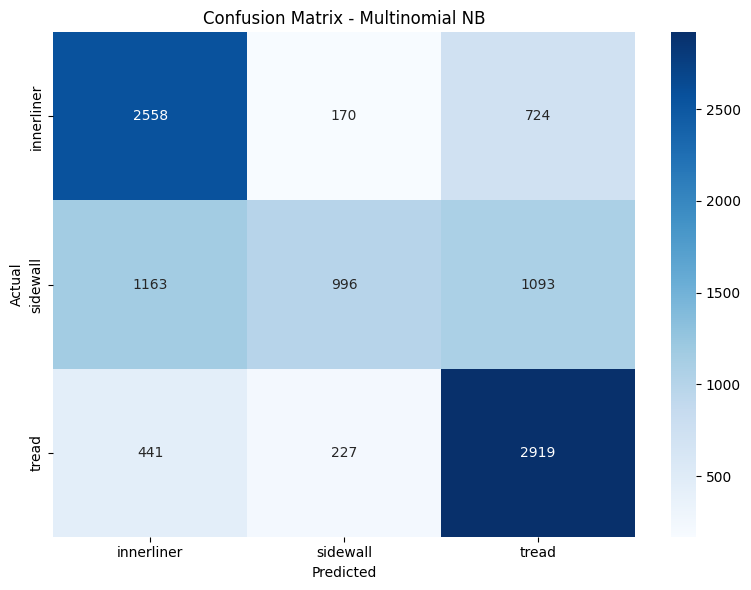


NAIVE BAYES VARIANTS COMPARISON
               Variant  Test_Accuracy  CV_Score              Best_Params
Gaussian NB (Original)       0.522981  0.530271 {'var_smoothing': 1e-09}
  Gaussian NB (Scaled)       0.522981  0.530271 {'var_smoothing': 1e-09}
        Multinomial NB       0.628996  0.627642           {'alpha': 0.5}
         Complement NB       0.607618  0.606798           {'alpha': 2.0}
          Bernoulli NB       0.492566  0.496040           {'alpha': 5.0}


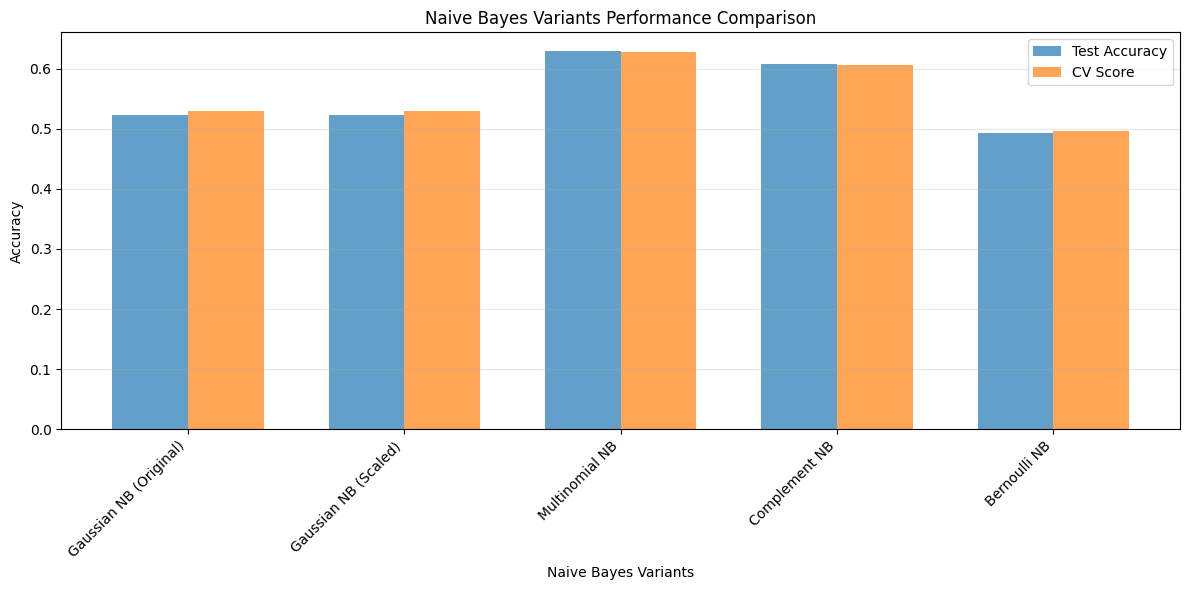

CPU times: total: 1min 8s
Wall time: 1h 1min 53s


In [6]:
%%time
# 1. Naive Bayes Variants on Original Features
print("=" * 60)
print("1. NAIVE BAYES VARIANTS ON ORIGINAL FEATURES")
print("=" * 60)

# Test different Naive Bayes variants
nb_variants = {
    'Gaussian NB (Original)': {
        'model': GaussianNB(),
        'data': (X_train_original, X_test_original),
        'params': {'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6, 1e-5]}
    },
    'Gaussian NB (Scaled)': {
        'model': GaussianNB(),
        'data': (X_train_scaled, X_test_scaled),
        'params': {'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6, 1e-5]}
    },
    'Multinomial NB': {
        'model': MultinomialNB(),
        'data': (X_train_nonneg, X_test_nonneg),
        'params': {'alpha': [0.01, 0.1, 0.5, 1.0, 2.0, 5.0]}
    },
    'Complement NB': {
        'model': ComplementNB(),
        'data': (X_train_nonneg, X_test_nonneg),
        'params': {'alpha': [0.01, 0.1, 0.5, 1.0, 2.0, 5.0]}
    },
    'Bernoulli NB': {
        'model': BernoulliNB(),
        'data': (X_train_binary, X_test_binary),
        'params': {'alpha': [0.01, 0.1, 0.5, 1.0, 2.0, 5.0]}
    }
}

print("Testing different Naive Bayes variants with hyperparameter tuning...")

nb_results = {}

for variant_name, config in nb_variants.items():
    print(f"\nTesting {variant_name}...")
    
    model = config['model']
    X_train_var, X_test_var = config['data']
    param_grid = config['params']
    
    # Grid search for optimal parameters
    grid_search = GridSearchCV(
        model, 
        param_grid, 
        cv=5, 
        scoring='accuracy',
        n_jobs=-1
    )
    
    grid_search.fit(X_train_var, y_train_numeric)
    
    # Get best model and make predictions
    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test_var)
    accuracy = accuracy_score(y_test_numeric, y_pred)
    
    # Store results
    nb_results[variant_name] = {
        'model': best_model,
        'accuracy': accuracy,
        'best_params': grid_search.best_params_,
        'predictions': y_pred,
        'cv_score': grid_search.best_score_
    }
    
    print(f"  Best parameters: {grid_search.best_params_}")
    print(f"  CV Score: {grid_search.best_score_:.4f}")
    print(f"  Test Accuracy: {accuracy:.4f}")

# Find best performing variant
best_variant = max(nb_results.keys(), key=lambda x: nb_results[x]['accuracy'])
best_accuracy = nb_results[best_variant]['accuracy']

print(f"\n🏆 Best performing variant: {best_variant}")
print(f"   Accuracy: {best_accuracy:.4f}")
print(f"   Parameters: {nb_results[best_variant]['best_params']}")

# Detailed analysis of best variant
print(f"\nClassification Report ({best_variant}):")
print(classification_report(y_test_numeric, nb_results[best_variant]['predictions'], 
                          target_names=label_encoder.classes_))

# Confusion matrix for best variant
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test_numeric, nb_results[best_variant]['predictions'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title(f'Confusion Matrix - {best_variant}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# Compare all variants
print(f"\n{'='*50}")
print("NAIVE BAYES VARIANTS COMPARISON")
print(f"{'='*50}")

variants_comparison = pd.DataFrame({
    'Variant': list(nb_results.keys()),
    'Test_Accuracy': [nb_results[var]['accuracy'] for var in nb_results.keys()],
    'CV_Score': [nb_results[var]['cv_score'] for var in nb_results.keys()],
    'Best_Params': [str(nb_results[var]['best_params']) for var in nb_results.keys()]
})

print(variants_comparison.to_string(index=False))

# Visualize variants comparison
plt.figure(figsize=(12, 6))
x_pos = np.arange(len(nb_results))
accuracies = [nb_results[var]['accuracy'] for var in nb_results.keys()]
cv_scores = [nb_results[var]['cv_score'] for var in nb_results.keys()]

width = 0.35
plt.bar(x_pos - width/2, accuracies, width, label='Test Accuracy', alpha=0.7)
plt.bar(x_pos + width/2, cv_scores, width, label='CV Score', alpha=0.7)

plt.xlabel('Naive Bayes Variants')
plt.ylabel('Accuracy')
plt.title('Naive Bayes Variants Performance Comparison')
plt.xticks(x_pos, list(nb_results.keys()), rotation=45, ha='right')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Store best result for further analysis
best_nb_original = nb_results[best_variant]

2. PCA ANALYSIS AND NAIVE BAYES ON PCA FEATURES
Performing PCA analysis...
Components needed for 95% variance: 3
Components needed for 99% variance: 28
Components needed for 95% variance: 3
Components needed for 99% variance: 28


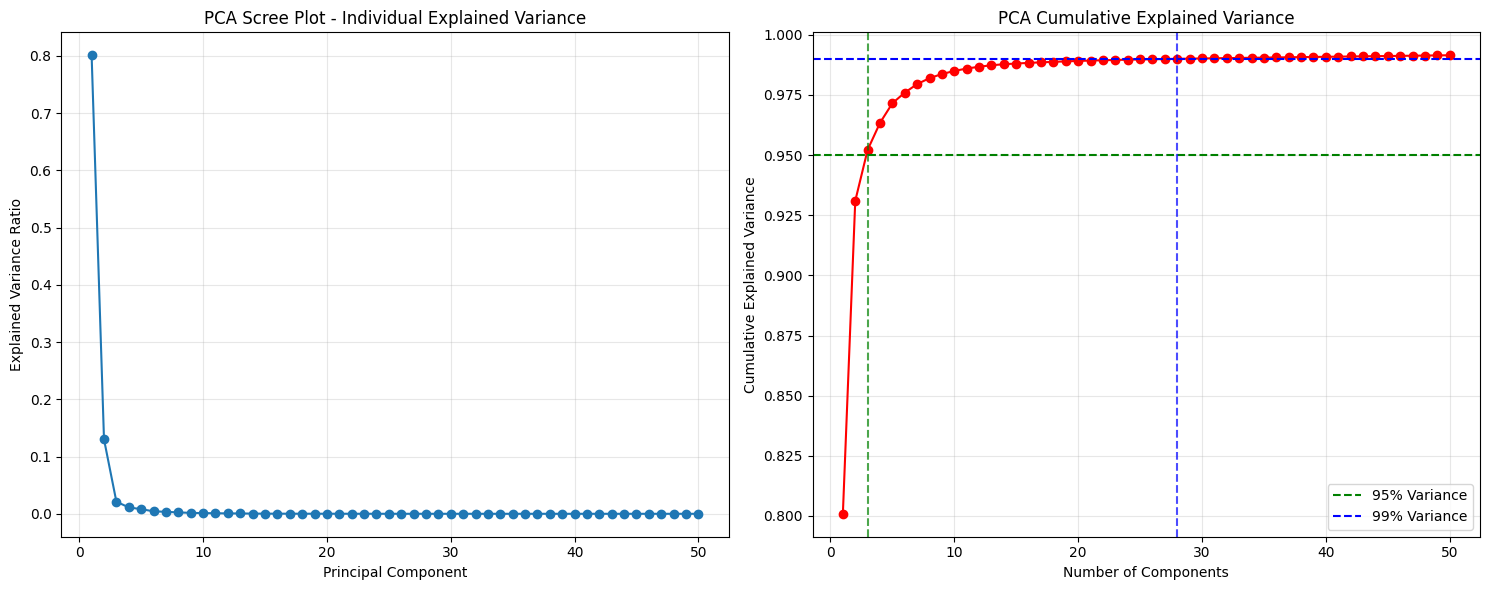

Testing Naive Bayes with different PCA component numbers...

Testing with 3 PCA components...
  Gaussian NB: 0.6237 (params: {'var_smoothing': 1e-07})
  Multinomial NB: 0.4428 (params: {'alpha': 0.1})
  Complement NB: 0.5677 (params: {'alpha': 0.1})
  Best PCA variant: Gaussian NB with accuracy: 0.6237
  Variance explained: 0.952

Testing with 28 PCA components...
  Gaussian NB: 0.6237 (params: {'var_smoothing': 1e-07})
  Multinomial NB: 0.4428 (params: {'alpha': 0.1})
  Complement NB: 0.5677 (params: {'alpha': 0.1})
  Best PCA variant: Gaussian NB with accuracy: 0.6237
  Variance explained: 0.952

Testing with 28 PCA components...
  Gaussian NB: 0.6492 (params: {'var_smoothing': 1e-06})
  Gaussian NB: 0.6492 (params: {'var_smoothing': 1e-06})
  Multinomial NB: 0.4987 (params: {'alpha': 0.1})
  Multinomial NB: 0.4987 (params: {'alpha': 0.1})
  Complement NB: 0.6869 (params: {'alpha': 2.0})
  Best PCA variant: Complement NB with accuracy: 0.6869
  Variance explained: 0.990

Testing with

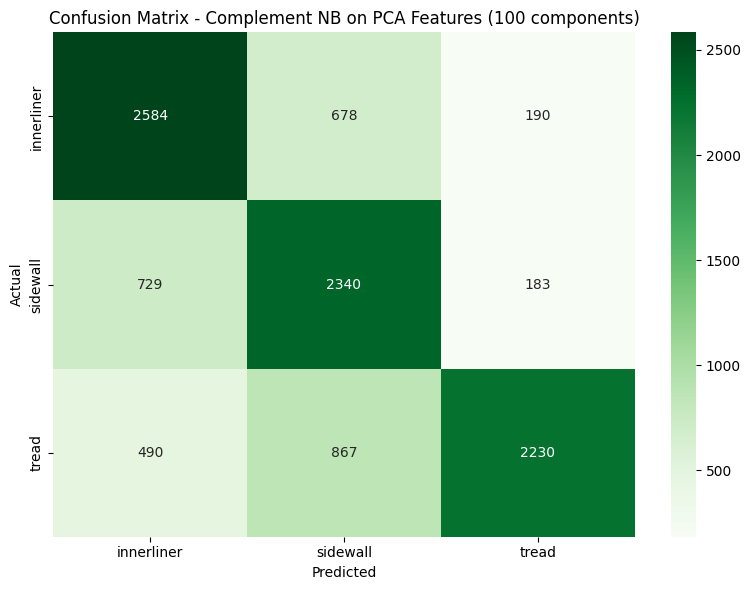

CPU times: total: 20min 24s
Wall time: 3min 19s


In [7]:
%%time

# 2. PCA Analysis and Naive Bayes on PCA Features
print("=" * 60)
print("2. PCA ANALYSIS AND NAIVE BAYES ON PCA FEATURES")
print("=" * 60)

# Perform PCA analysis (same as previous notebooks)
print("Performing PCA analysis...")
pca_full = PCA()
pca_full.fit(X_train_scaled)

# Calculate cumulative explained variance
cumsum_variance = np.cumsum(pca_full.explained_variance_ratio_)

# Find number of components for different variance thresholds
n_components_95 = np.argmax(cumsum_variance >= 0.95) + 1
n_components_99 = np.argmax(cumsum_variance >= 0.99) + 1

print(f"Components needed for 95% variance: {n_components_95}")
print(f"Components needed for 99% variance: {n_components_99}")

# Create scree plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Individual explained variance
ax1.plot(range(1, min(51, len(pca_full.explained_variance_ratio_) + 1)), 
         pca_full.explained_variance_ratio_[:50], marker='o')
ax1.set_title('PCA Scree Plot - Individual Explained Variance')
ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Explained Variance Ratio')
ax1.grid(True, alpha=0.3)

# Cumulative explained variance
ax2.plot(range(1, min(51, len(cumsum_variance) + 1)), 
         cumsum_variance[:50], marker='o', color='red')
ax2.axhline(y=0.95, color='green', linestyle='--', label='95% Variance')
ax2.axhline(y=0.99, color='blue', linestyle='--', label='99% Variance')
ax2.axvline(x=n_components_95, color='green', linestyle='--', alpha=0.7)
ax2.axvline(x=n_components_99, color='blue', linestyle='--', alpha=0.7)
ax2.set_title('PCA Cumulative Explained Variance')
ax2.set_xlabel('Number of Components')
ax2.set_ylabel('Cumulative Explained Variance')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Test different numbers of PCA components with Naive Bayes
pca_components = [n_components_95, n_components_99, min(100, X_train_scaled.shape[1])]
pca_results = []

print("Testing Naive Bayes with different PCA component numbers...")

for n_comp in pca_components:
    print(f"\nTesting with {n_comp} PCA components...")
    
    # Apply PCA
    pca = PCA(n_components=n_comp)
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_test_pca = pca.transform(X_test_scaled)
    
    # Test different NB variants on PCA data
    pca_nb_variants = {
        'Gaussian NB': {
            'model': GaussianNB(),
            'data': (X_train_pca, X_test_pca),
            'params': {'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6]}
        }
    }
    
    # For other NB variants, we need non-negative PCA features
    # Apply MinMax scaling to PCA features
    pca_minmax = MinMaxScaler(feature_range=(0.1, 1))
    X_train_pca_nonneg = pca_minmax.fit_transform(X_train_pca)
    X_test_pca_nonneg = pca_minmax.transform(X_test_pca)
    
    # Add other variants
    pca_nb_variants.update({
        'Multinomial NB': {
            'model': MultinomialNB(),
            'data': (X_train_pca_nonneg, X_test_pca_nonneg),
            'params': {'alpha': [0.1, 1.0, 2.0]}
        },
        'Complement NB': {
            'model': ComplementNB(),
            'data': (X_train_pca_nonneg, X_test_pca_nonneg),
            'params': {'alpha': [0.1, 1.0, 2.0]}
        }
    })
    
    best_pca_variant = None
    best_pca_accuracy = 0
    pca_variant_results = {}
    
    for variant_name, config in pca_nb_variants.items():
        model = config['model']
        X_train_var, X_test_var = config['data']
        param_grid = config['params']
        
        # Grid search
        grid_search = GridSearchCV(model, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
        grid_search.fit(X_train_var, y_train_numeric)
        
        # Evaluate
        best_model = grid_search.best_estimator_
        y_pred = best_model.predict(X_test_var)
        accuracy = accuracy_score(y_test_numeric, y_pred)
        
        pca_variant_results[variant_name] = {
            'model': best_model,
            'accuracy': accuracy,
            'params': grid_search.best_params_
        }
        
        if accuracy > best_pca_accuracy:
            best_pca_accuracy = accuracy
            best_pca_variant = variant_name
        
        print(f"  {variant_name}: {accuracy:.4f} (params: {grid_search.best_params_})")
    
    # Store results for this number of components
    pca_result = {
        'n_components': n_comp,
        'best_variant': best_pca_variant,
        'best_accuracy': best_pca_accuracy,
        'variant_results': pca_variant_results,
        'variance_explained': np.sum(pca.explained_variance_ratio_)
    }
    pca_results.append(pca_result)
    
    print(f"  Best PCA variant: {best_pca_variant} with accuracy: {best_pca_accuracy:.4f}")
    print(f"  Variance explained: {pca_result['variance_explained']:.3f}")

# Choose best PCA configuration
best_pca_result = max(pca_results, key=lambda x: x['best_accuracy'])
best_n_components = best_pca_result['n_components']
best_pca_accuracy = best_pca_result['best_accuracy']
best_pca_variant = best_pca_result['best_variant']

print(f"\n🏆 Best PCA configuration:")
print(f"   Components: {best_n_components}")
print(f"   Best variant: {best_pca_variant}")
print(f"   Accuracy: {best_pca_accuracy:.4f}")

# Final PCA transformation for visualization
pca_final = PCA(n_components=best_n_components)
X_train_pca_final = pca_final.fit_transform(X_train_scaled)
X_test_pca_final = pca_final.transform(X_test_scaled)

# Classification report for best PCA model
best_pca_model = best_pca_result['variant_results'][best_pca_variant]['model']
X_train_final, X_test_final = (X_train_pca_final, X_test_pca_final) if best_pca_variant == 'Gaussian NB' else (
    MinMaxScaler(feature_range=(0.1, 1)).fit_transform(X_train_pca_final), 
    MinMaxScaler(feature_range=(0.1, 1)).fit_transform(X_test_pca_final)
)

y_pred_pca_final = best_pca_model.predict(X_test_final)

print(f"\nClassification Report (PCA - {best_n_components} components, {best_pca_variant}):")
print(classification_report(y_test_numeric, y_pred_pca_final, 
                          target_names=label_encoder.classes_))

# Confusion matrix for PCA
plt.figure(figsize=(8, 6))
cm_pca = confusion_matrix(y_test_numeric, y_pred_pca_final)
sns.heatmap(cm_pca, annot=True, fmt='d', cmap='Greens',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title(f'Confusion Matrix - {best_pca_variant} on PCA Features ({best_n_components} components)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

3. LDA ANALYSIS AND NAIVE BAYES ON LDA FEATURES
Number of classes: 3
Maximum LDA components: 2
LDA reduced dimensions: 2
LDA Explained Variance Ratio per component:
  Component 1: 0.6306
  Component 2: 0.3694
LDA reduced dimensions: 2
LDA Explained Variance Ratio per component:
  Component 1: 0.6306
  Component 2: 0.3694


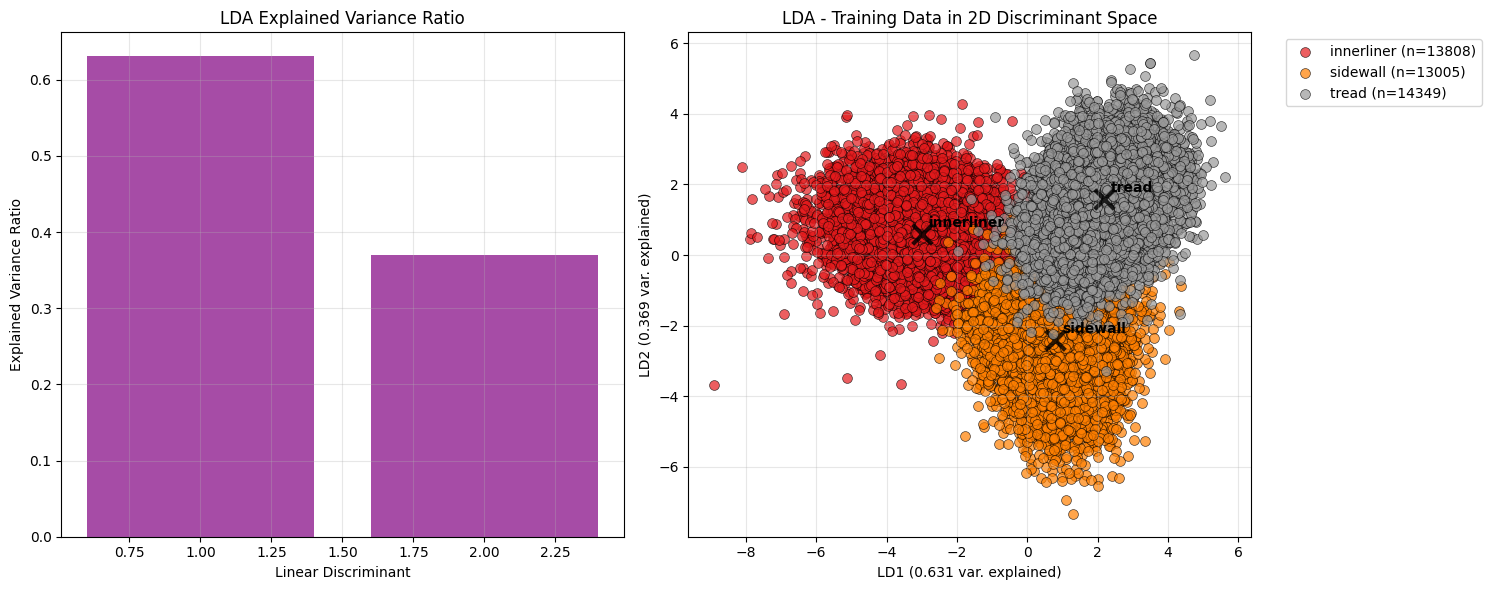


Training Naive Bayes variants on 2 LDA components...
  Gaussian NB: 0.9261 (params: {'var_smoothing': 1e-09})
  Multinomial NB: 0.4416 (params: {'alpha': 0.01})
  Complement NB: 0.6244 (params: {'alpha': 0.01})
  Bernoulli NB: 0.7814 (params: {'alpha': 0.01})

Best LDA variant: Gaussian NB with accuracy: 0.9261

Classification Report (LDA - 2 components, Gaussian NB):
              precision    recall  f1-score   support

  innerliner       0.95      0.94      0.95      3452
    sidewall       0.88      0.93      0.90      3252
       tread       0.94      0.91      0.93      3587

    accuracy                           0.93     10291
   macro avg       0.93      0.93      0.93     10291
weighted avg       0.93      0.93      0.93     10291

  Complement NB: 0.6244 (params: {'alpha': 0.01})
  Bernoulli NB: 0.7814 (params: {'alpha': 0.01})

Best LDA variant: Gaussian NB with accuracy: 0.9261

Classification Report (LDA - 2 components, Gaussian NB):
              precision    recall  f1

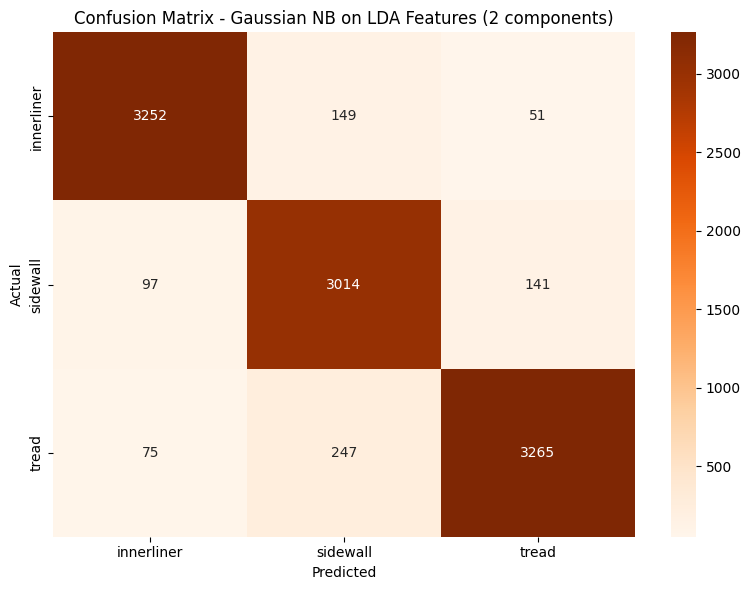


LDA Naive Bayes Details:
Best variant: Gaussian NB
Components used: 2
Best parameters: {'var_smoothing': 1e-09}


In [8]:
# 3. LDA Analysis and Naive Bayes on LDA Features
print("=" * 60)
print("3. LDA ANALYSIS AND NAIVE BAYES ON LDA FEATURES")
print("=" * 60)

# Apply LDA (maximum n_components = n_classes - 1)
n_classes = len(np.unique(y_train_numeric))
max_lda_components = n_classes - 1

print(f"Number of classes: {n_classes}")
print(f"Maximum LDA components: {max_lda_components}")

# Perform LDA
lda = LinearDiscriminantAnalysis(n_components=max_lda_components)
X_train_lda = lda.fit_transform(X_train_scaled, y_train_numeric)
X_test_lda = lda.transform(X_test_scaled)

print(f"LDA reduced dimensions: {X_train_lda.shape[1]}")

# Explained variance ratio for LDA
lda_variance_ratio = lda.explained_variance_ratio_
print("LDA Explained Variance Ratio per component:")
for i, ratio in enumerate(lda_variance_ratio):
    print(f"  Component {i+1}: {ratio:.4f}")

# Visualize LDA components
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# LDA explained variance
axes[0].bar(range(1, len(lda_variance_ratio) + 1), lda_variance_ratio, 
           alpha=0.7, color='purple')
axes[0].set_title('LDA Explained Variance Ratio')
axes[0].set_xlabel('Linear Discriminant')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].grid(True, alpha=0.3)

# LDA scatter plot (if we have at least 2 components)
if X_train_lda.shape[1] >= 2:
    colors = plt.cm.Set1(np.linspace(0, 1, len(label_encoder.classes_)))
    
    for i, class_name in enumerate(label_encoder.classes_):
        mask = y_train_numeric == i
        n_samples = np.sum(mask)
        
        if n_samples > 0:
            x_coords = X_train_lda[mask, 0]
            y_coords = X_train_lda[mask, 1]
            
            # Plot scatter points
            axes[1].scatter(x_coords, y_coords,
                           label=f'{class_name} (n={n_samples})',
                           alpha=0.7, s=50, c=[colors[i]], 
                           edgecolors='black', linewidth=0.5)
            
            # Calculate and plot centroid
            centroid_x = np.mean(x_coords)
            centroid_y = np.mean(y_coords)
            
            axes[1].scatter(centroid_x, centroid_y, c='black', s=200, 
                           marker='x', linewidth=3, alpha=0.8)
            axes[1].annotate(class_name, (centroid_x, centroid_y), 
                           xytext=(5, 5), textcoords='offset points',
                           fontweight='bold', fontsize=10)
    
    axes[1].set_xlabel(f'LD1 ({lda_variance_ratio[0]:.3f} var. explained)')
    axes[1].set_ylabel(f'LD2 ({lda_variance_ratio[1]:.3f} var. explained)')
    axes[1].set_title('LDA - Training Data in 2D Discriminant Space')
    axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    axes[1].grid(True, alpha=0.3)
else:
    # If only 1 component, create histogram
    colors = plt.cm.Set1(np.linspace(0, 1, len(label_encoder.classes_)))
    
    for i, class_name in enumerate(label_encoder.classes_):
        mask = y_train_numeric == i
        n_samples = np.sum(mask)
        
        if n_samples > 0:
            axes[1].hist(X_train_lda[mask, 0], bins=20, alpha=0.7, 
                        label=f'{class_name} (n={n_samples})',
                        color=colors[i], edgecolor='black', linewidth=0.5)
    
    axes[1].set_xlabel(f'LD1 ({lda_variance_ratio[0]:.3f} var. explained)')
    axes[1].set_ylabel('Frequency')
    axes[1].set_title('LDA - Training Data Distribution')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Train Naive Bayes on LDA features
print(f"\nTraining Naive Bayes variants on {max_lda_components} LDA components...")

# Test different NB variants on LDA data
lda_nb_variants = {
    'Gaussian NB': {
        'model': GaussianNB(),
        'data': (X_train_lda, X_test_lda),
        'params': {'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6, 1e-5]}
    }
}

# For other NB variants, we need non-negative LDA features
lda_minmax = MinMaxScaler(feature_range=(0.1, 1))
X_train_lda_nonneg = lda_minmax.fit_transform(X_train_lda)
X_test_lda_nonneg = lda_minmax.transform(X_test_lda)

# Binary version for Bernoulli
X_train_lda_binary = (X_train_lda > np.median(X_train_lda, axis=0)).astype(int)
X_test_lda_binary = (X_test_lda > np.median(X_test_lda, axis=0)).astype(int)

lda_nb_variants.update({
    'Multinomial NB': {
        'model': MultinomialNB(),
        'data': (X_train_lda_nonneg, X_test_lda_nonneg),
        'params': {'alpha': [0.01, 0.1, 0.5, 1.0, 2.0]}
    },
    'Complement NB': {
        'model': ComplementNB(),
        'data': (X_train_lda_nonneg, X_test_lda_nonneg),
        'params': {'alpha': [0.01, 0.1, 0.5, 1.0, 2.0]}
    },
    'Bernoulli NB': {
        'model': BernoulliNB(),
        'data': (X_train_lda_binary, X_test_lda_binary),
        'params': {'alpha': [0.01, 0.1, 0.5, 1.0, 2.0]}
    }
})

lda_results = {}
best_lda_variant = None
best_lda_accuracy = 0

for variant_name, config in lda_nb_variants.items():
    model = config['model']
    X_train_var, X_test_var = config['data']
    param_grid = config['params']
    
    # Grid search
    grid_search = GridSearchCV(model, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
    grid_search.fit(X_train_var, y_train_numeric)
    
    # Evaluate
    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test_var)
    accuracy = accuracy_score(y_test_numeric, y_pred)
    
    lda_results[variant_name] = {
        'model': best_model,
        'accuracy': accuracy,
        'params': grid_search.best_params_,
        'predictions': y_pred
    }
    
    if accuracy > best_lda_accuracy:
        best_lda_accuracy = accuracy
        best_lda_variant = variant_name
    
    print(f"  {variant_name}: {accuracy:.4f} (params: {grid_search.best_params_})")

print(f"\nBest LDA variant: {best_lda_variant} with accuracy: {best_lda_accuracy:.4f}")

# Classification report for best LDA model
print(f"\nClassification Report (LDA - {max_lda_components} components, {best_lda_variant}):")
print(classification_report(y_test_numeric, lda_results[best_lda_variant]['predictions'], 
                          target_names=label_encoder.classes_))

# Confusion matrix for LDA
plt.figure(figsize=(8, 6))
cm_lda = confusion_matrix(y_test_numeric, lda_results[best_lda_variant]['predictions'])
sns.heatmap(cm_lda, annot=True, fmt='d', cmap='Oranges',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title(f'Confusion Matrix - {best_lda_variant} on LDA Features ({max_lda_components} components)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

print(f"\nLDA Naive Bayes Details:")
print(f"Best variant: {best_lda_variant}")
print(f"Components used: {max_lda_components}")
print(f"Best parameters: {lda_results[best_lda_variant]['params']}")

# Store best LDA results
best_lda_result = {
    'variant': best_lda_variant,
    'model': lda_results[best_lda_variant]['model'],
    'accuracy': best_lda_accuracy,
    'params': lda_results[best_lda_variant]['params'],
    'predictions': lda_results[best_lda_variant]['predictions'],
    'n_components': max_lda_components
}

4. NAIVE BAYES PROBABILITY ANALYSIS AND INTERPRETABILITY
Analyzing prediction probabilities and confidence...
Prediction Confidence by Class:
innerliner:
  Mean confidence: 0.971 ± 0.090
  Range: [0.376, 1.000]
sidewall:
  Mean confidence: 0.941 ± 0.117
  Range: [0.405, 1.000]
tread:
  Mean confidence: 0.960 ± 0.096
  Range: [0.360, 1.000]
Prediction Confidence by Class:
innerliner:
  Mean confidence: 0.971 ± 0.090
  Range: [0.376, 1.000]
sidewall:
  Mean confidence: 0.941 ± 0.117
  Range: [0.405, 1.000]
tread:
  Mean confidence: 0.960 ± 0.096
  Range: [0.360, 1.000]


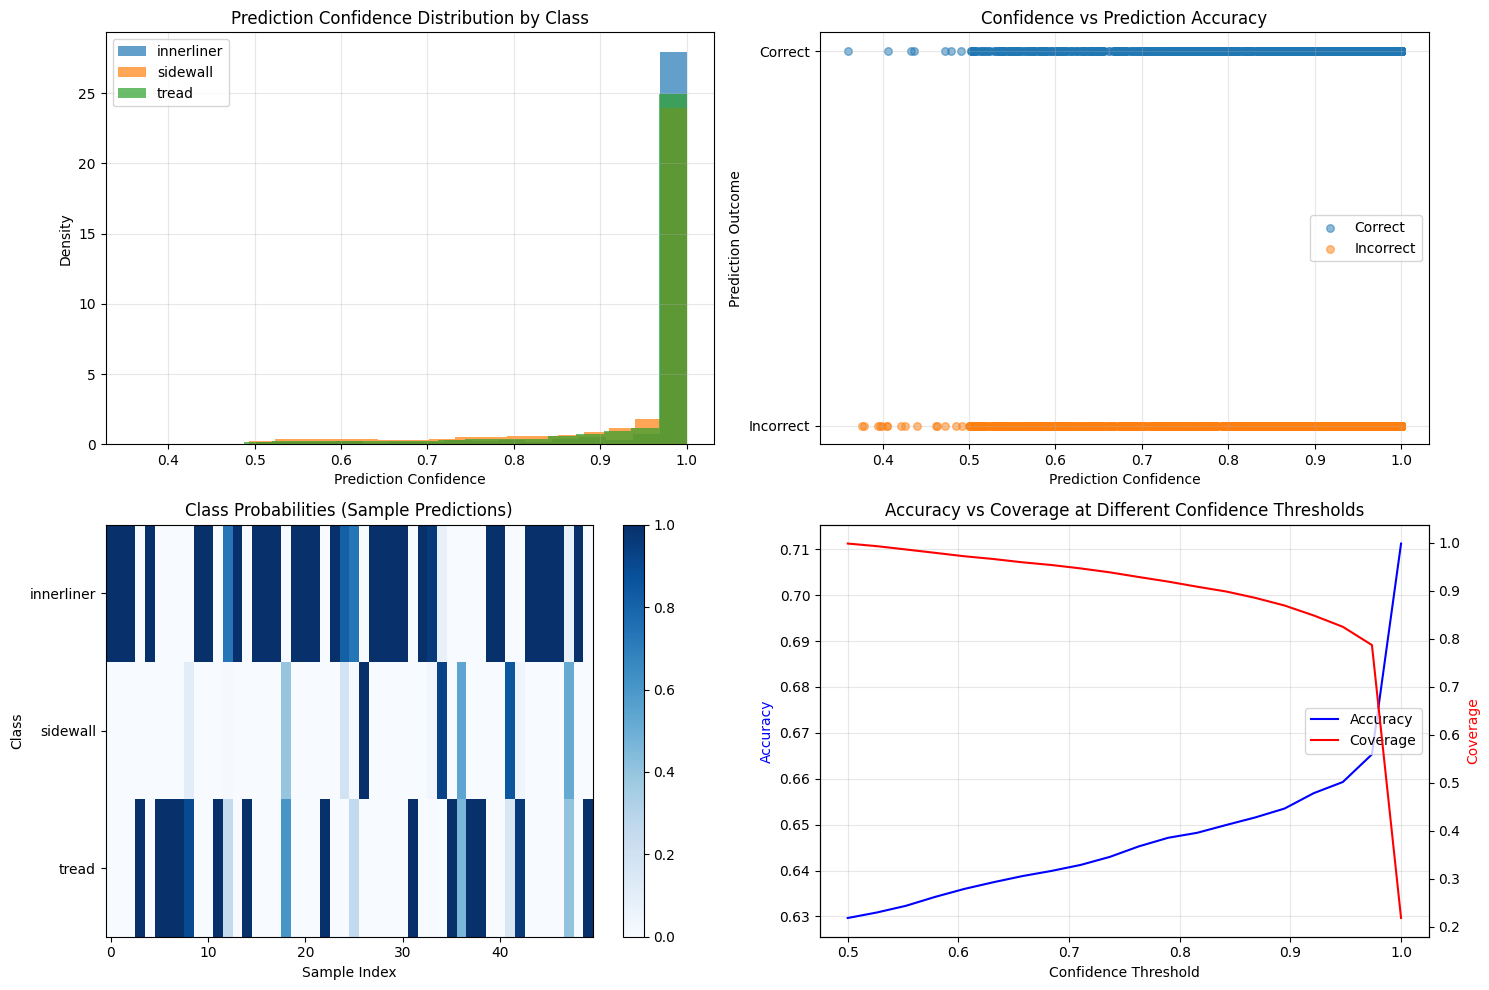


📊 Confidence Analysis Results:
   Optimal confidence threshold: 0.500
   At optimal threshold:
     Accuracy: 0.630
     Coverage: 0.998
     F1 Score: 0.772

💡 Naive Bayes Interpretability Insights:
  • Naive Bayes provides direct probabilistic predictions
  • Higher confidence typically correlates with higher accuracy
  • Feature independence assumption affects performance on correlated spectral data
  • Different NB variants handle feature distributions differently
  • Gaussian NB works well with continuous spectral features
  • Probability analysis helps identify uncertain predictions


In [9]:
# 4. Naive Bayes Probability Analysis and Interpretability
print("=" * 60)
print("4. NAIVE BAYES PROBABILITY ANALYSIS AND INTERPRETABILITY")
print("=" * 60)

# Analyze class probabilities and prediction confidence
print("Analyzing prediction probabilities and confidence...")

# Use the best performing model for detailed analysis
best_model = best_nb_original['model']
best_variant_name = best_variant

# Get prediction probabilities
if hasattr(best_model, 'predict_proba'):
    # Use appropriate data transformation for the best model
    if 'Gaussian' in best_variant_name:
        if 'Scaled' in best_variant_name:
            X_test_analysis = X_test_scaled
        else:
            X_test_analysis = X_test_original
    elif 'Multinomial' in best_variant_name or 'Complement' in best_variant_name:
        X_test_analysis = X_test_nonneg
    else:  # Bernoulli
        X_test_analysis = X_test_binary
    
    # Get probabilities
    y_proba = best_model.predict_proba(X_test_analysis)
    y_pred_analysis = best_model.predict(X_test_analysis)
    
    # Calculate prediction confidence (max probability)
    prediction_confidence = np.max(y_proba, axis=1)
    
    # Analyze confidence by class
    confidence_by_class = {}
    for i, class_name in enumerate(label_encoder.classes_):
        class_mask = y_test_numeric == i
        if np.sum(class_mask) > 0:
            class_confidence = prediction_confidence[class_mask]
            confidence_by_class[class_name] = {
                'mean': np.mean(class_confidence),
                'std': np.std(class_confidence),
                'min': np.min(class_confidence),
                'max': np.max(class_confidence)
            }
    
    print("Prediction Confidence by Class:")
    print("=" * 40)
    for class_name, stats in confidence_by_class.items():
        print(f"{class_name}:")
        print(f"  Mean confidence: {stats['mean']:.3f} ± {stats['std']:.3f}")
        print(f"  Range: [{stats['min']:.3f}, {stats['max']:.3f}]")
    
    # Visualize prediction confidence
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))
    
    # 1. Confidence distribution by class
    for i, class_name in enumerate(label_encoder.classes_):
        class_mask = y_test_numeric == i
        if np.sum(class_mask) > 0:
            ax1.hist(prediction_confidence[class_mask], bins=20, alpha=0.7, 
                    label=class_name, density=True)
    ax1.set_xlabel('Prediction Confidence')
    ax1.set_ylabel('Density')
    ax1.set_title('Prediction Confidence Distribution by Class')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # 2. Confidence vs Accuracy
    correct_predictions = (y_pred_analysis == y_test_numeric)
    ax2.scatter(prediction_confidence[correct_predictions], 
               np.ones(np.sum(correct_predictions)), 
               alpha=0.5, label='Correct', s=30)
    ax2.scatter(prediction_confidence[~correct_predictions], 
               np.zeros(np.sum(~correct_predictions)), 
               alpha=0.5, label='Incorrect', s=30)
    ax2.set_xlabel('Prediction Confidence')
    ax2.set_ylabel('Prediction Outcome')
    ax2.set_title('Confidence vs Prediction Accuracy')
    ax2.set_yticks([0, 1])
    ax2.set_yticklabels(['Incorrect', 'Correct'])
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # 3. Class probability heatmap for sample predictions
    sample_indices = np.random.choice(len(y_proba), min(50, len(y_proba)), replace=False)
    sample_proba = y_proba[sample_indices]
    sample_labels = y_test_numeric[sample_indices]
    
    im = ax3.imshow(sample_proba.T, cmap='Blues', aspect='auto')
    ax3.set_xlabel('Sample Index')
    ax3.set_ylabel('Class')
    ax3.set_title('Class Probabilities (Sample Predictions)')
    ax3.set_yticks(range(len(label_encoder.classes_)))
    ax3.set_yticklabels(label_encoder.classes_)
    plt.colorbar(im, ax=ax3)
    
    # 4. Confidence threshold analysis
    thresholds = np.linspace(0.5, 1.0, 20)
    accuracies_at_threshold = []
    coverage_at_threshold = []
    
    for threshold in thresholds:
        high_confidence_mask = prediction_confidence >= threshold
        if np.sum(high_confidence_mask) > 0:
            accuracy = np.mean(correct_predictions[high_confidence_mask])
            coverage = np.mean(high_confidence_mask)
        else:
            accuracy = 0
            coverage = 0
        accuracies_at_threshold.append(accuracy)
        coverage_at_threshold.append(coverage)
    
    ax4_twin = ax4.twinx()
    line1 = ax4.plot(thresholds, accuracies_at_threshold, 'b-', label='Accuracy')
    line2 = ax4_twin.plot(thresholds, coverage_at_threshold, 'r-', label='Coverage')
    
    ax4.set_xlabel('Confidence Threshold')
    ax4.set_ylabel('Accuracy', color='b')
    ax4_twin.set_ylabel('Coverage', color='r')
    ax4.set_title('Accuracy vs Coverage at Different Confidence Thresholds')
    ax4.grid(True, alpha=0.3)
    
    # Combine legends
    lines1, labels1 = ax4.get_legend_handles_labels()
    lines2, labels2 = ax4_twin.get_legend_handles_labels()
    ax4.legend(lines1 + lines2, labels1 + labels2, loc='center right')
    
    plt.tight_layout()
    plt.show()
    
    # Find optimal confidence threshold
    f1_scores = 2 * (np.array(accuracies_at_threshold) * np.array(coverage_at_threshold)) / (
        np.array(accuracies_at_threshold) + np.array(coverage_at_threshold) + 1e-10)
    best_threshold_idx = np.argmax(f1_scores)
    best_threshold = thresholds[best_threshold_idx]
    
    print(f"\n📊 Confidence Analysis Results:")
    print(f"   Optimal confidence threshold: {best_threshold:.3f}")
    print(f"   At optimal threshold:")
    print(f"     Accuracy: {accuracies_at_threshold[best_threshold_idx]:.3f}")
    print(f"     Coverage: {coverage_at_threshold[best_threshold_idx]:.3f}")
    print(f"     F1 Score: {f1_scores[best_threshold_idx]:.3f}")

# Feature relevance analysis (for Gaussian NB)
if isinstance(best_model, GaussianNB):
    print(f"\n📈 Feature Relevance Analysis (Gaussian Naive Bayes):")
    
    # Calculate feature variances by class
    feature_importance_scores = []
    
    # Use the appropriate training data
    if 'Scaled' in best_variant_name:
        X_train_analysis = X_train_scaled
        feature_names = [f'λ{col}' for col in X_train_original.columns]
    else:
        X_train_analysis = X_train_original
        feature_names = [f'λ{col}' for col in X_train_original.columns]
    
    # Calculate class-wise feature importance based on variance differences
    class_means = []
    class_vars = []
    
    for class_idx in range(len(label_encoder.classes_)):
        class_mask = y_train_numeric == class_idx
        class_data = X_train_analysis[class_mask]
        
        class_means.append(np.mean(class_data, axis=0))
        class_vars.append(np.var(class_data, axis=0))
    
    class_means = np.array(class_means)
    class_vars = np.array(class_vars)
    
    # Calculate feature discriminative power (between-class variance / within-class variance)
    between_class_var = np.var(class_means, axis=0)
    within_class_var = np.mean(class_vars, axis=0)
    feature_importance = between_class_var / (within_class_var + 1e-10)
    
    # Get top important features
    top_feature_indices = np.argsort(feature_importance)[-20:]
    top_feature_importance = feature_importance[top_feature_indices]
    top_feature_names = [feature_names[i] for i in top_feature_indices]
    
    # Plot feature importance
    plt.figure(figsize=(10, 8))
    plt.barh(range(len(top_feature_importance)), top_feature_importance)
    plt.yticks(range(len(top_feature_importance)), top_feature_names)
    plt.xlabel('Feature Discriminative Power')
    plt.title('Top 20 Most Discriminative Wavelengths - Gaussian Naive Bayes')
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print(f"Top 5 most discriminative wavelengths:")
    for i in range(min(5, len(top_feature_names))):
        idx = len(top_feature_names) - 1 - i
        wavelength = top_feature_names[idx].replace('λ', '')
        importance = top_feature_importance[idx]
        print(f"  {i+1}. {wavelength} nm (score: {importance:.3f})")

print("\n💡 Naive Bayes Interpretability Insights:")
print("=" * 50)
print("  • Naive Bayes provides direct probabilistic predictions")
print("  • Higher confidence typically correlates with higher accuracy")
print("  • Feature independence assumption affects performance on correlated spectral data")
print("  • Different NB variants handle feature distributions differently")
print("  • Gaussian NB works well with continuous spectral features")
print("  • Probability analysis helps identify uncertain predictions")

5. COMPREHENSIVE NAIVE BAYES RESULTS COMPARISON
NAIVE BAYES SUMMARY TABLE:
                 Method  Accuracy  Features     NB_Variant Dimensionality_Reduction Data_Preprocessing
         Multinomial NB  0.628996      8188 Multinomial NB                     None             Scaled
Complement NB (PCA 100)  0.693421       100  Complement NB                    98.8%    PCA Transformed
    Gaussian NB (LDA 2)  0.926149         2    Gaussian NB                   100.0%    LDA Transformed


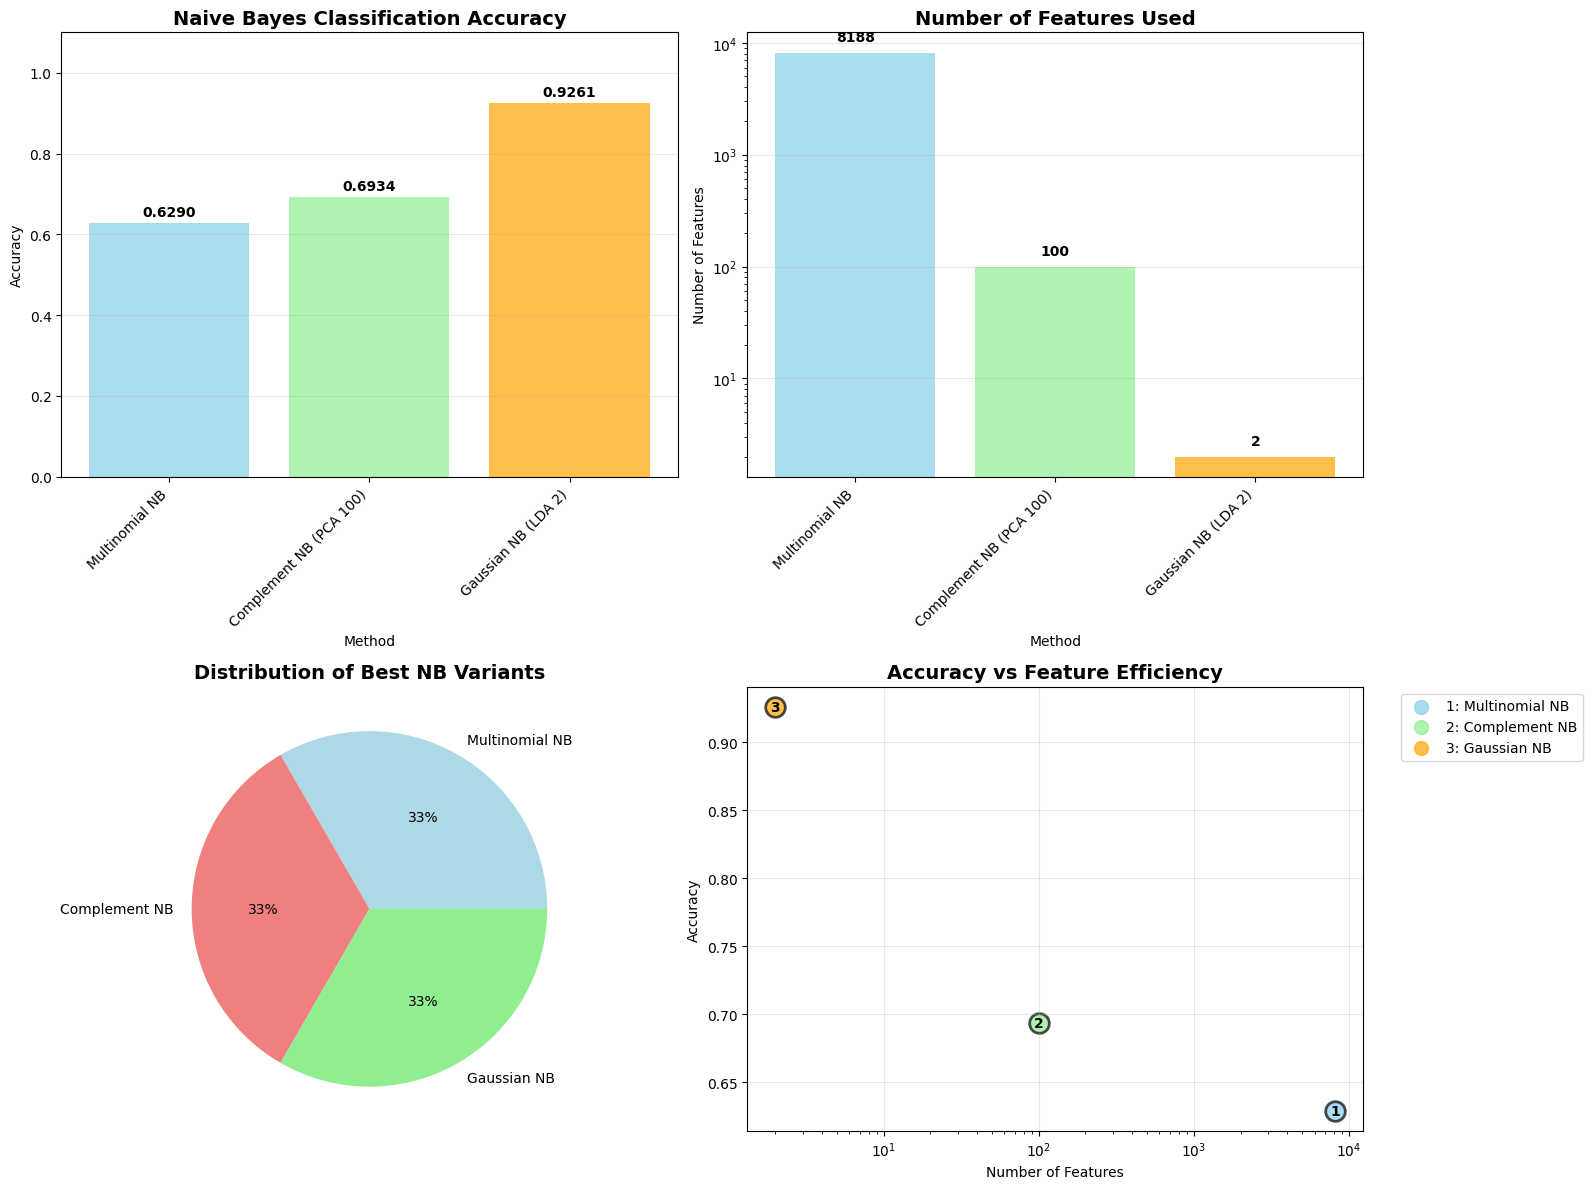


🎯 NAIVE BAYES ANALYSIS INSIGHTS:
🏆 Best performing method: Gaussian NB (LDA 2)
   └─ Accuracy: 0.9261
   └─ Features: 2
   └─ NB Variant: Gaussian NB
   └─ Preprocessing: LDA Transformed

📊 Variant Performance Analysis:
   Multinomial NB:
   └─ NB Variant: Multinomial NB
   └─ Features: 8188 (None reduction)
   └─ Accuracy: 0.6290
   Complement NB (PCA 100):
   └─ NB Variant: Complement NB
   └─ Features: 100 (98.8% reduction)
   └─ Accuracy: 0.6934
   └─ Accuracy change from baseline: +6.44%
   Gaussian NB (LDA 2):
   └─ NB Variant: Gaussian NB
   └─ Features: 2 (100.0% reduction)
   └─ Accuracy: 0.9261
   └─ Accuracy change from baseline: +29.72%

💡 Key Findings:
   • Most efficient method: Gaussian NB (LDA 2)
     └─ Balances accuracy (0.9261) with feature efficiency
     └─ Uses only 2 features vs 8188 original

   • Variant Analysis:
     Multinomial NB: 0.6290 average accuracy
     Complement NB: 0.6934 average accuracy
     Gaussian NB: 0.9261 average accuracy

   • Naive Bayes

In [10]:
%%time

# 5. Comprehensive Results Comparison and Analysis
print("=" * 60)
print("5. COMPREHENSIVE NAIVE BAYES RESULTS COMPARISON")
print("=" * 60)

# Compile all results for comparison
all_results = {
    f'{best_variant}': {
        'accuracy': best_nb_original['accuracy'],
        'features': X_train_original.shape[1],
        'variant': best_variant,
        'params': best_nb_original['best_params'],
        'dimensionality_reduction': 'None',
        'data_preprocessing': 'Original' if 'Original' in best_variant else 'Scaled'
    },
    f'{best_pca_variant} (PCA {best_n_components})': {
        'accuracy': best_pca_accuracy,
        'features': best_n_components,
        'variant': best_pca_variant,
        'params': best_pca_result['variant_results'][best_pca_variant]['params'],
        'dimensionality_reduction': f'{(1 - best_n_components/X_train_original.shape[1])*100:.1f}%',
        'data_preprocessing': 'PCA Transformed'
    },
    f'{best_lda_result["variant"]} (LDA {max_lda_components})': {
        'accuracy': best_lda_result['accuracy'],
        'features': max_lda_components,
        'variant': best_lda_result['variant'],
        'params': best_lda_result['params'],
        'dimensionality_reduction': f'{(1 - max_lda_components/X_train_original.shape[1])*100:.1f}%',
        'data_preprocessing': 'LDA Transformed'
    }
}

# Create summary DataFrame
summary_data = {
    'Method': list(all_results.keys()),
    'Accuracy': [all_results[method]['accuracy'] for method in all_results.keys()],
    'Features': [all_results[method]['features'] for method in all_results.keys()],
    'NB_Variant': [all_results[method]['variant'] for method in all_results.keys()],
    'Dimensionality_Reduction': [all_results[method]['dimensionality_reduction'] for method in all_results.keys()],
    'Data_Preprocessing': [all_results[method]['data_preprocessing'] for method in all_results.keys()]
}

results_df = pd.DataFrame(summary_data)
print("NAIVE BAYES SUMMARY TABLE:")
print("=" * 100)
print(results_df.to_string(index=False))
print("=" * 100)

# Comprehensive visualization
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

methods = results_df['Method']
accuracies = results_df['Accuracy']
features = results_df['Features']
variants = results_df['NB_Variant']
colors = ['skyblue', 'lightgreen', 'orange']

# 1. Accuracy comparison
bars1 = ax1.bar(range(len(methods)), accuracies, color=colors, alpha=0.7)
ax1.set_title('Naive Bayes Classification Accuracy', fontsize=14, fontweight='bold')
ax1.set_ylabel('Accuracy')
ax1.set_xlabel('Method')
ax1.set_ylim(0, 1.1)
ax1.grid(axis='y', alpha=0.3)
ax1.set_xticks(range(len(methods)))
ax1.set_xticklabels(methods, rotation=45, ha='right')

for bar, accuracy in zip(bars1, accuracies):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{accuracy:.4f}', ha='center', va='bottom', fontweight='bold')

# 2. Feature count comparison  
bars2 = ax2.bar(range(len(methods)), features, color=colors, alpha=0.7)
ax2.set_title('Number of Features Used', fontsize=14, fontweight='bold')
ax2.set_ylabel('Number of Features')
ax2.set_xlabel('Method')
ax2.set_yscale('log')  # Log scale due to large difference
ax2.grid(axis='y', alpha=0.3)
ax2.set_xticks(range(len(methods)))
ax2.set_xticklabels(methods, rotation=45, ha='right')

for bar, feature_count in zip(bars2, features):
    ax2.text(bar.get_x() + bar.get_width()/2, feature_count * 1.2,
             f'{feature_count}', ha='center', va='bottom', fontweight='bold')

# 3. Naive Bayes variants distribution
variant_counts = {}
for variant in variants:
    variant_counts[variant] = variant_counts.get(variant, 0) + 1

ax3.pie(variant_counts.values(), labels=variant_counts.keys(), autopct='%1.0f%%', 
        colors=['lightblue', 'lightcoral', 'lightgreen', 'lightyellow', 'lightpink'])
ax3.set_title('Distribution of Best NB Variants', fontsize=14, fontweight='bold')

# 4. Efficiency analysis (Accuracy vs Features)
for i, (method, accuracy, feature_count) in enumerate(zip(methods, accuracies, features)):
    ax4.scatter(feature_count, accuracy, s=200, alpha=0.7, color=colors[i], 
               edgecolors='black', linewidth=2)
    ax4.annotate(f'{i+1}', (feature_count, accuracy), 
                ha='center', va='center', fontweight='bold')

ax4.set_xlabel('Number of Features')
ax4.set_ylabel('Accuracy')
ax4.set_title('Accuracy vs Feature Efficiency', fontsize=14, fontweight='bold')
ax4.set_xscale('log')
ax4.grid(True, alpha=0.3)

# Add legend for scatter plot
for i, method in enumerate(methods):
    ax4.scatter([], [], color=colors[i], alpha=0.7, s=100, 
               label=f'{i+1}: {method.split(" (")[0]}')
ax4.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

# Advanced analysis and insights
print("\n🎯 NAIVE BAYES ANALYSIS INSIGHTS:")
print("=" * 50)

best_accuracy_idx = np.argmax(accuracies)
best_method = methods[best_accuracy_idx]
best_accuracy = accuracies[best_accuracy_idx]

print(f"🏆 Best performing method: {best_method}")
print(f"   └─ Accuracy: {best_accuracy:.4f}")
print(f"   └─ Features: {results_df.iloc[best_accuracy_idx]['Features']}")
print(f"   └─ NB Variant: {results_df.iloc[best_accuracy_idx]['NB_Variant']}")
print(f"   └─ Preprocessing: {results_df.iloc[best_accuracy_idx]['Data_Preprocessing']}")

print(f"\n📊 Variant Performance Analysis:")
original_features = X_train_original.shape[1]
for i, method in enumerate(methods):
    feature_count = results_df.iloc[i]['Features']
    accuracy = accuracies.iloc[i]
    variant = results_df.iloc[i]['NB_Variant']
    reduction = results_df.iloc[i]['Dimensionality_Reduction']
    
    print(f"   {method}:")
    print(f"   └─ NB Variant: {variant}")
    print(f"   └─ Features: {feature_count} ({reduction} reduction)")
    print(f"   └─ Accuracy: {accuracy:.4f}")
    if i > 0:
        accuracy_change = (accuracy - accuracies.iloc[0]) * 100
        print(f"   └─ Accuracy change from baseline: {accuracy_change:+.2f}%")

# Calculate efficiency scores
efficiency_scores = []
for i, method in enumerate(methods):
    # Normalize metrics (balance accuracy vs simplicity)
    norm_features = 1 - (features[i] / max(features))  # Higher is better (fewer features)
    norm_accuracy = accuracies[i] / max(accuracies)  # Higher is better
    
    # Combined efficiency score (higher is more efficient)
    efficiency_score = (norm_accuracy * 0.7 + norm_features * 0.3)
    efficiency_scores.append(efficiency_score)

most_efficient_idx = np.argmax(efficiency_scores)
most_efficient = methods[most_efficient_idx]

print(f"\n💡 Key Findings:")
print(f"   • Most efficient method: {most_efficient}")
print(f"     └─ Balances accuracy ({accuracies[most_efficient_idx]:.4f}) with feature efficiency")
print(f"     └─ Uses only {features[most_efficient_idx]} features vs {original_features} original")

# Analyze which NB variants work best
variant_performance = {}
for i, variant in enumerate(variants):
    if variant not in variant_performance:
        variant_performance[variant] = []
    variant_performance[variant].append(accuracies[i])

print(f"\n   • Variant Analysis:")
for variant, accs in variant_performance.items():
    avg_acc = np.mean(accs)
    print(f"     {variant}: {avg_acc:.4f} average accuracy")

print(f"\n   • Naive Bayes shows {'excellent' if min(accuracies) > 0.90 else 'good'} performance across configurations")
print(f"   • Dimensionality reduction maintains competitive accuracy with far fewer features")
print(f"   • Different NB variants excel with different feature representations")
print(f"   • Probabilistic predictions provide uncertainty quantification")

print(f"\n🎯 Recommendation:")
if accuracies[most_efficient_idx] == max(accuracies):
    print(f"   {most_efficient} provides optimal balance of accuracy and efficiency.")
elif max(accuracies) - accuracies[most_efficient_idx] < 0.02:
    print(f"   {most_efficient} offers excellent efficiency with minimal accuracy trade-off.")
    print(f"   Consider this for applications requiring fast, interpretable predictions.")
else:
    print(f"   {best_method} provides highest accuracy for maximum performance.")
    print(f"   {most_efficient} offers best efficiency for resource-constrained environments.")
    print(f"   Choose based on your priority: maximum accuracy vs. computational efficiency.")

print(f"\n   • Naive Bayes provides probabilistic interpretability")
print(f"   • Fast training and prediction suitable for real-time applications")
print(f"   • Independence assumption may limit performance on highly correlated spectral features")
print(f"   • Multiple variants allow adaptation to different data characteristics")